# 第 11 章 OpenCV 邊緣偵測

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from opencv_tools import opencv_tools # 匯入封裝的功能

### 11-1-3 程式範例：Sobel 運算子的應用

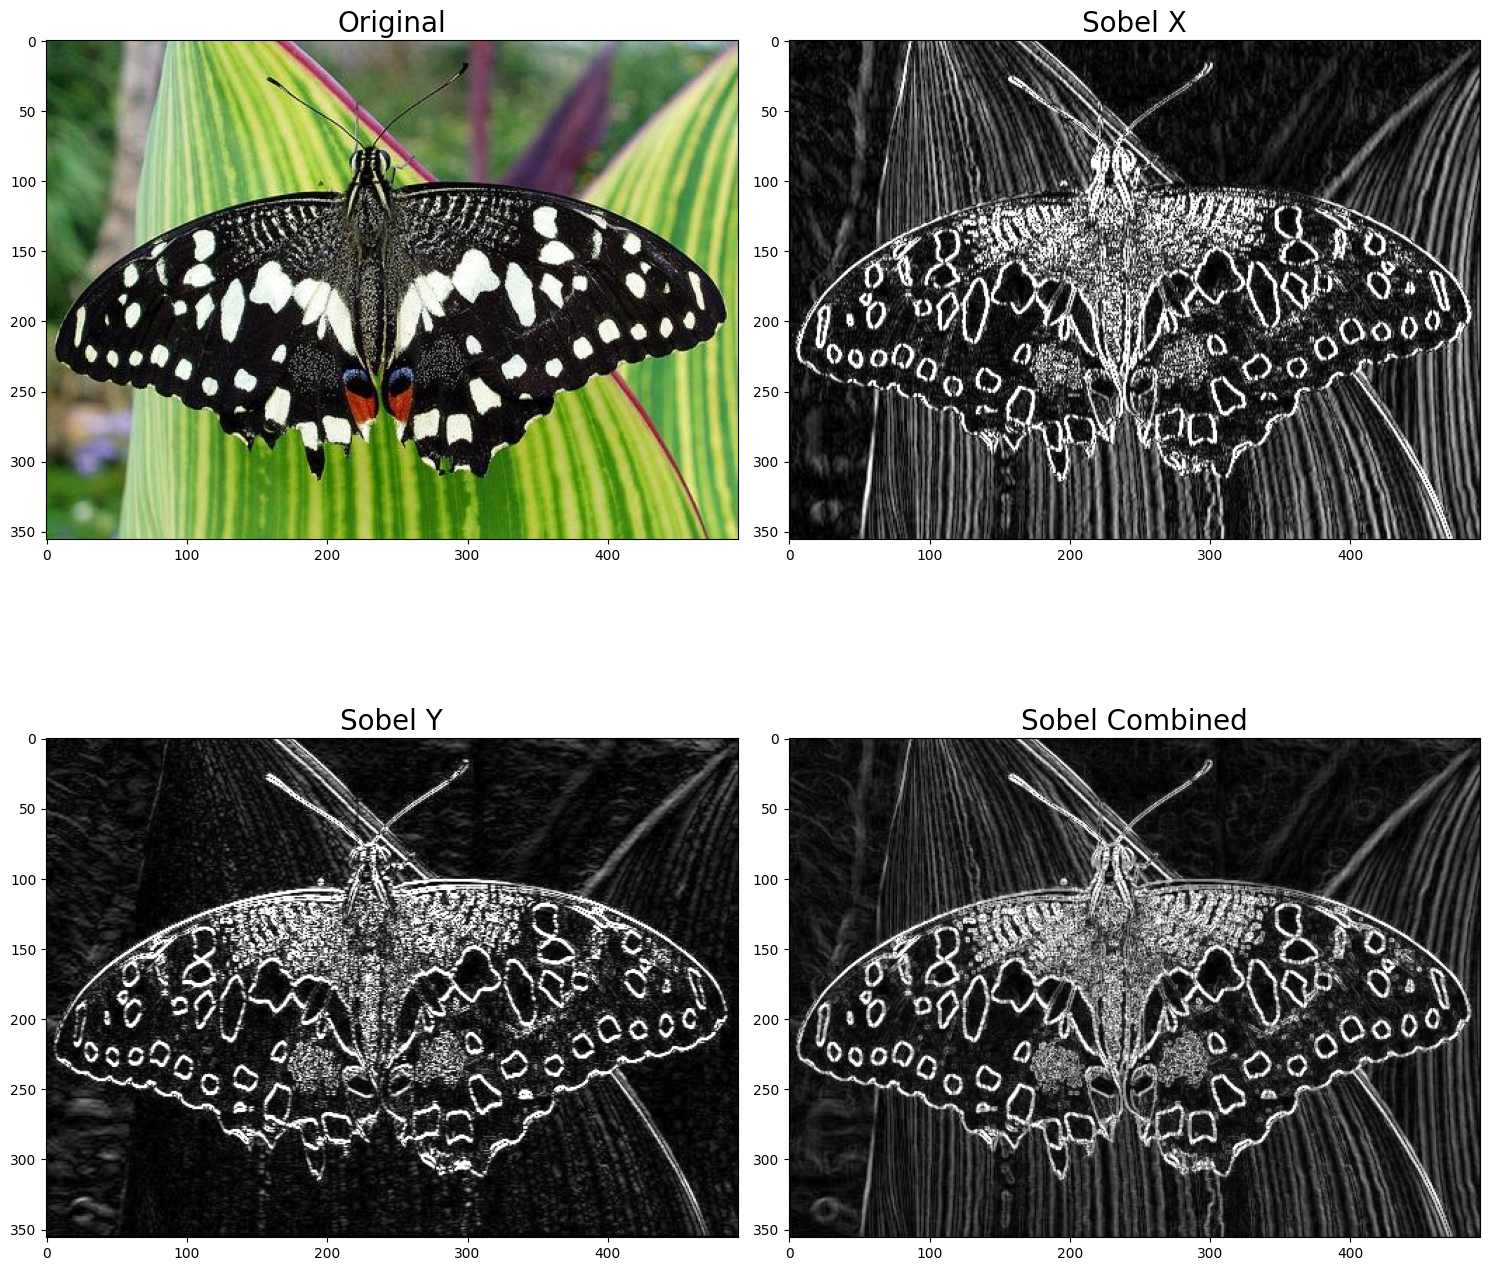

In [2]:
# 讀取原始影像並轉為灰階
img = cv2.imread('sample/butterfly.jpg')
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# dx=1：捕捉水平方向的變化，偵測垂直邊緣
sobel_x = cv2.Sobel(gray, cv2.CV_64F, dx=1, dy=0, ksize=3)
# dy=1：捕捉垂直方向的變化，偵測水平邊緣
sobel_y = cv2.Sobel(gray, cv2.CV_64F, dx=0, dy=1, ksize=3)

# 取絕對值（避免負梯度被截斷）
sobel_abs_x = cv2.convertScaleAbs(sobel_x)
sobel_abs_y = cv2.convertScaleAbs(sobel_y)

# 加權合併兩個方向的邊緣
sobel_combined = cv2.addWeighted(sobel_abs_x, 0.5, sobel_abs_y, 0.5, 0)

opencv_tools.show_img_by_matplotlib_2x2(
    'Original', img,
    'Sobel X', sobel_abs_x,
    'Sobel Y', sobel_abs_y,
    'Sobel Combined', sobel_combined
)

### 11-2-3 程式範例：Laplacian 運算子的應用

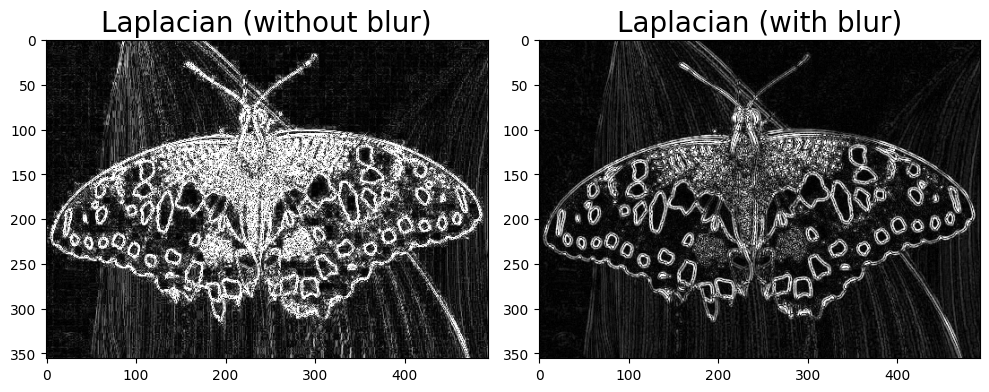

In [3]:
# 讀取原始影像並轉為灰階
img = cv2.imread('sample/butterfly.jpg')
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# 沒有做高斯模糊的情況
gray_laplacian = cv2.Laplacian(gray, cv2.CV_64F, ksize=3)
gray_laplacian_abs = cv2.convertScaleAbs(gray_laplacian)

# 先做高斯模糊，減少 Laplacian 的雜訊
blurred = cv2.GaussianBlur(gray, (3, 3), 0)

# 計算 Laplacian 邊緣偵測
blurred_laplacian = cv2.Laplacian(blurred, cv2.CV_64F, ksize=3)

# 將結果轉為絕對值
blurred_laplacian_abs = cv2.convertScaleAbs(blurred_laplacian)

# 顯示結果
opencv_tools.show_img_by_matplotlib_1x2(
    'Laplacian (without blur)', gray_laplacian_abs,
    'Laplacian (with blur)', blurred_laplacian_abs
)

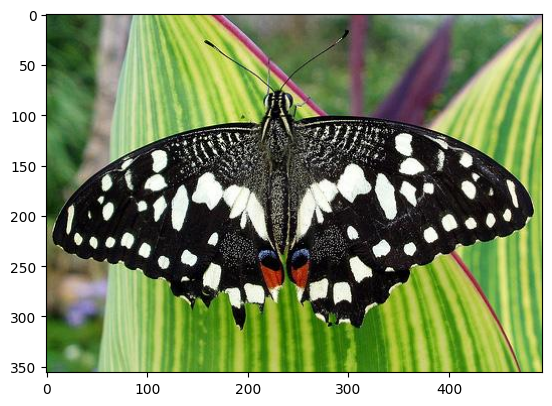

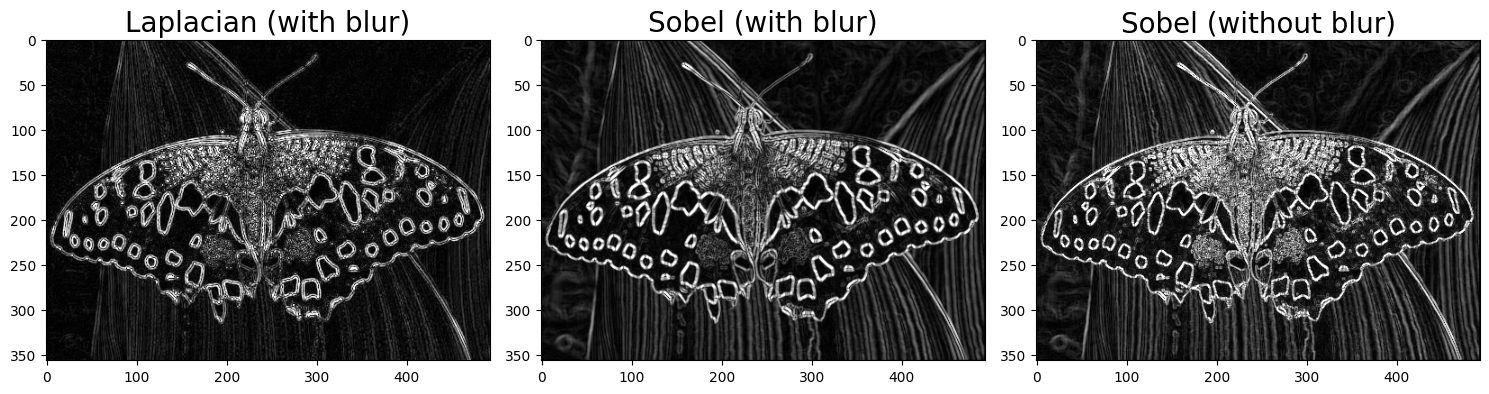

In [4]:
# 顯示原圖
opencv_tools.show_img_by_matplotlib(img)

# 計算 Sobel 邊緣偵測
sobel_blur_x = cv2.Sobel(blurred, cv2.CV_64F, dx=1, dy=0, ksize=3)
sobel_blur_y = cv2.Sobel(blurred, cv2.CV_64F, dx=0, dy=1, ksize=3)
sobel_blur_abs_x = cv2.convertScaleAbs(sobel_blur_x)
sobel_blur_abs_y = cv2.convertScaleAbs(sobel_blur_y)
sobel_blur_combined = cv2.addWeighted(sobel_blur_abs_x, 0.5, sobel_blur_abs_y, 0.5, 0)

# 顯示結果
opencv_tools.show_img_by_matplotlib_1x3(
    'Laplacian (with blur)', blurred_laplacian_abs,
    'Sobel (with blur)', sobel_blur_combined,
    'Sobel (without blur)', sobel_combined,
)

### 11-3-3 程式範例：Canny 運算子的應用

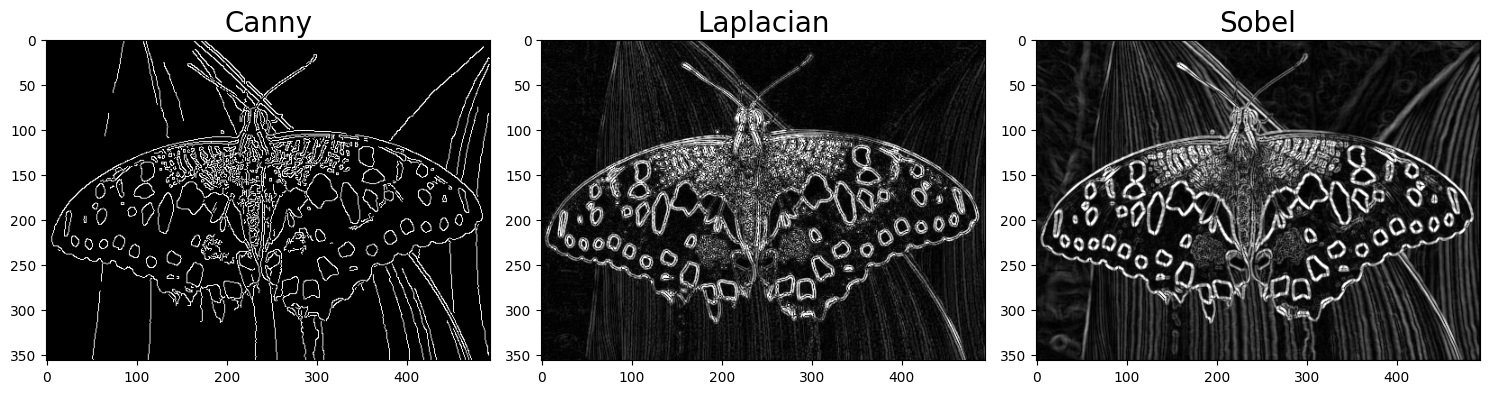

In [5]:
# 讀取原始影像並轉為灰階
img = cv2.imread('sample/butterfly.jpg')
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# 高斯模糊去雜訊
blur = cv2.GaussianBlur(gray, (3, 3), 0)

# 執行 Canny 邊緣偵測
canny = cv2.Canny(blur, 100, 200)

# 顯示結果
opencv_tools.show_img_by_matplotlib_1x3(        
    'Canny', canny,  
    'Laplacian', blurred_laplacian_abs,
    'Sobel', sobel_blur_combined
)

## 11-E 小專案：觀察不同的邊緣偵測方法效果

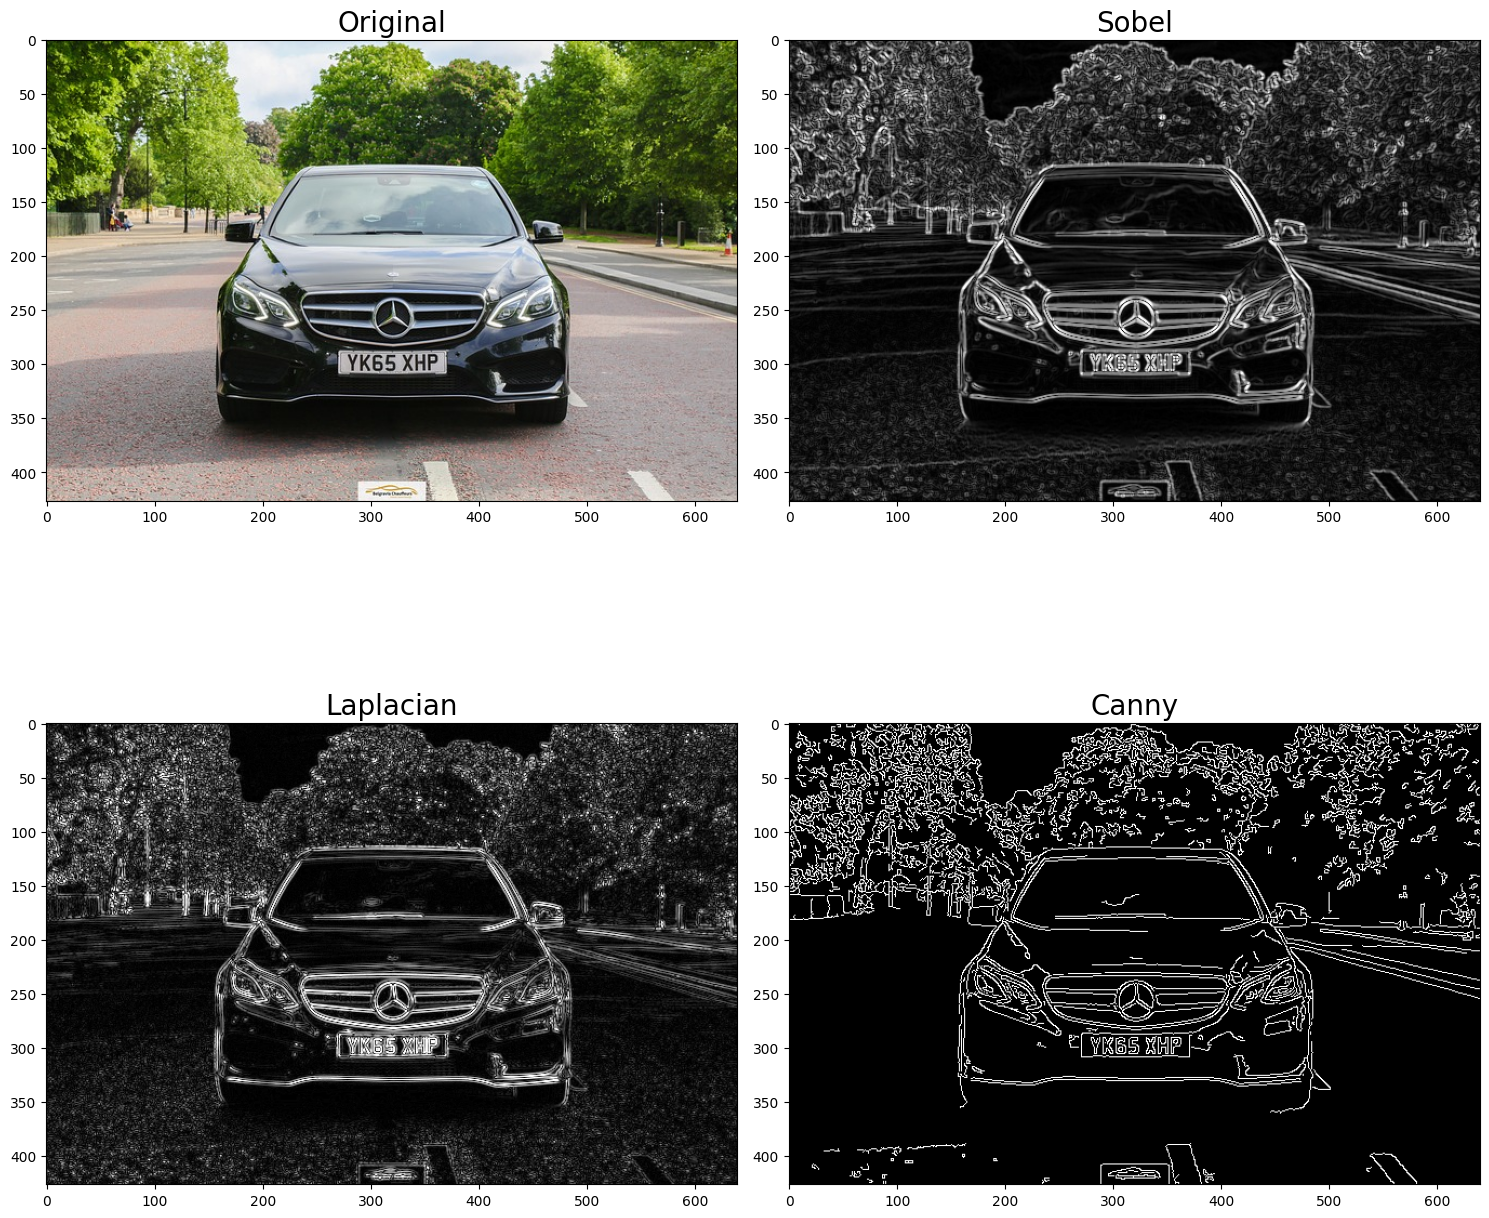

In [6]:
# 讀取原始影像並轉為灰階
img = cv2.imread('sample/car.jpg')
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# 高斯模糊去雜訊
blur = cv2.GaussianBlur(gray, (3, 3), 0)

# Sobel
sobel_x = cv2.Sobel(blur, cv2.CV_64F, dx=1, dy=0, ksize=3)
sobel_y = cv2.Sobel(blur, cv2.CV_64F, dx=0, dy=1, ksize=3)
sobel_abs_x = cv2.convertScaleAbs(sobel_x)
sobel_abs_y = cv2.convertScaleAbs(sobel_y)
sobel_combined = cv2.addWeighted(sobel_abs_x, 0.5, sobel_abs_y, 0.5, 0)

# Laplacian 
laplacian = cv2.Laplacian(blur, cv2.CV_64F, ksize=3)
laplacian_abs = cv2.convertScaleAbs(laplacian)

# Canny 
canny_edges = cv2.Canny(blur, 100, 200)

# 顯示結果
opencv_tools.show_img_by_matplotlib_2x2(
    'Original', img,
    'Sobel', sobel_combined,
    'Laplacian', laplacian_abs,
    'Canny', canny_edges    
)